
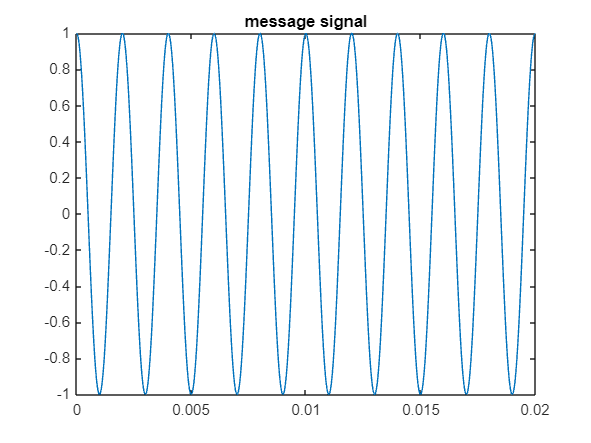

In [1]:
% using sine
clc;
clear;
close all;

Fs = 100000;
t = 0:1/Fs:0.02;

fm = 500;
fc = 5000;

m = cos(2*pi*fm*t);
c = cos(2*pi*fc*t);

% AM
mu = .8;
am = (1 + mu*m).*c;

% DSB-SC
dsb = m.*c;

% 6th order filter

[b,a]= butter(6, 1000/(Fs/2));

% envelop detector
env = abs(am);
recov_am = filter(b, a, env);

% coherent detector

coh_out = dsb.*c;
recov_dsb = filter(b, a, coh_out);

plot(t, m)
title("message signal")


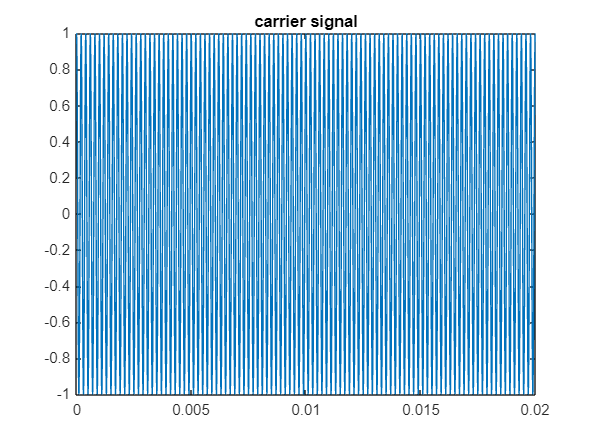

In [2]:

plot(t, c)
title("carrier signal")


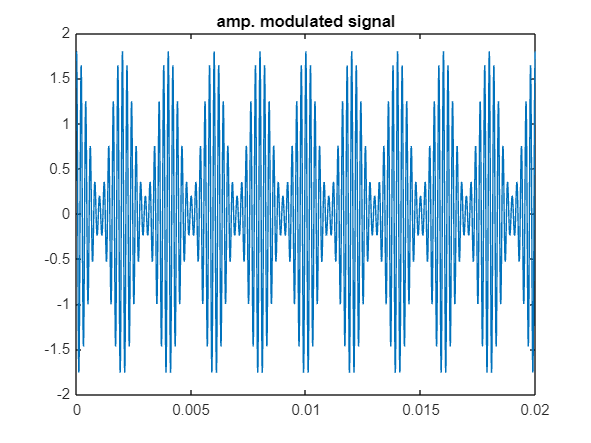

In [3]:

plot(t, am)
title("amp. modulated signal")


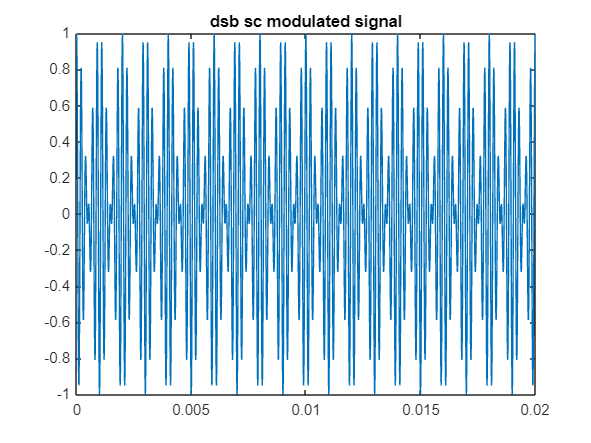

In [4]:

plot(t, dsb)
title("dsb sc modulated signal")


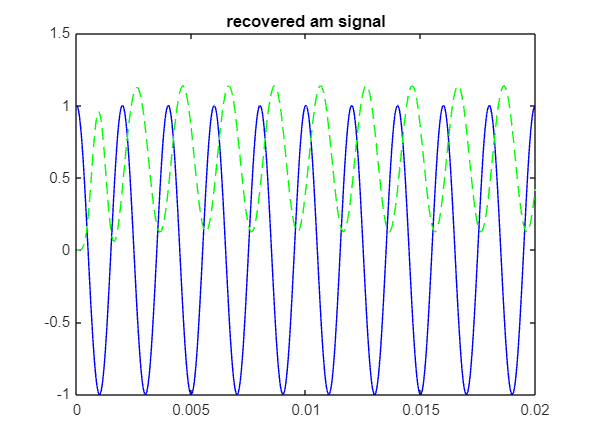

In [5]:

plot(t, m,'b',t, recov_am, 'g--')
title("recovered am signal")


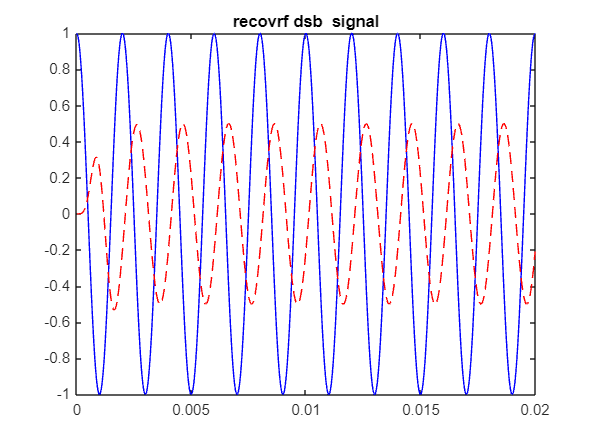

In [6]:

plot(t,m,'b',t,recov_dsb,'r--');
title("recovrf dsb  signal")


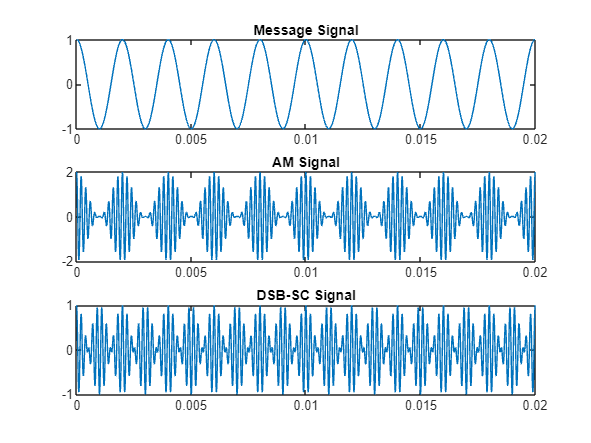

In [7]:
%using Cosine

clc;
clear;
close all;

Fs = 100000;
t = 0:1/Fs:0.02;

fm = 500;
fc = 5000;

m = cos(2*pi*fm*t);       % Message
c = cos(2*pi*fc*t);       % Carrier

% AM
mu = 1;
am = (1 + mu*m).*c;

% DSB-SC
dsb = m.*c;

figure;
subplot(3,1,1);
plot(t,m);
title('Message Signal');

subplot(3,1,2);
plot(t,am);
title('AM Signal');

subplot(3,1,3);
plot(t,dsb);
title('DSB-SC Signal');

## Envelope Detection for AM


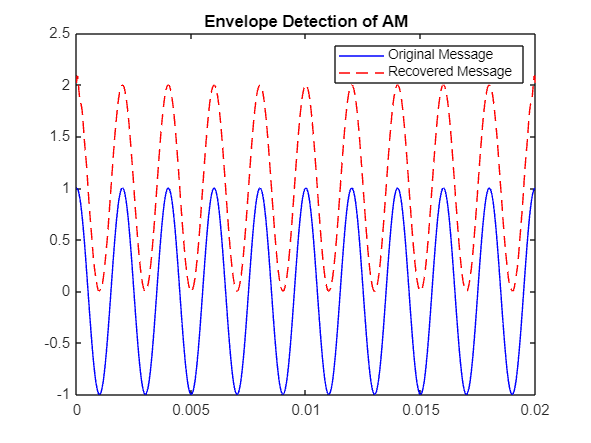

In [8]:
env_am = abs(hilbert(am));   % Envelope extraction
figure;
plot(t,m,'b',t,env_am,'r--');
title('Envelope Detection of AM');
legend('Original Message','Recovered Message');

## Coherent Detection for DSB\-SC

Multiply with local carrier (same frequency & phase)



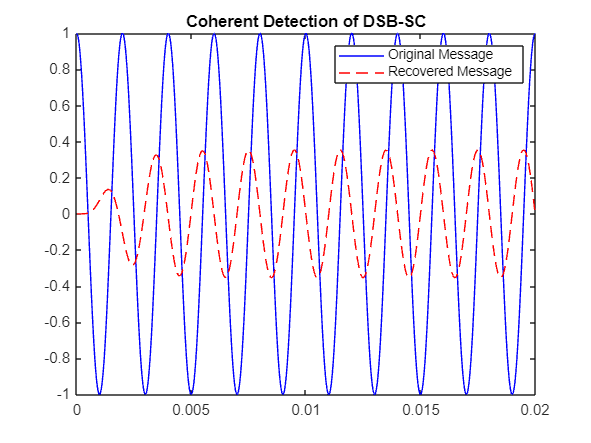

In [9]:
coherent_out = dsb .* c;

% Low-pass filter to remove high-frequency terms
[b,a] = butter(6, (fm*2)/(Fs));   % LPF cutoff slightly above fm
rec_dsb = filter(b,a,coherent_out);

figure;
plot(t,m,'b',t,rec_dsb,'r--');
title('Coherent Detection of DSB-SC');
legend('Original Message','Recovered Message');


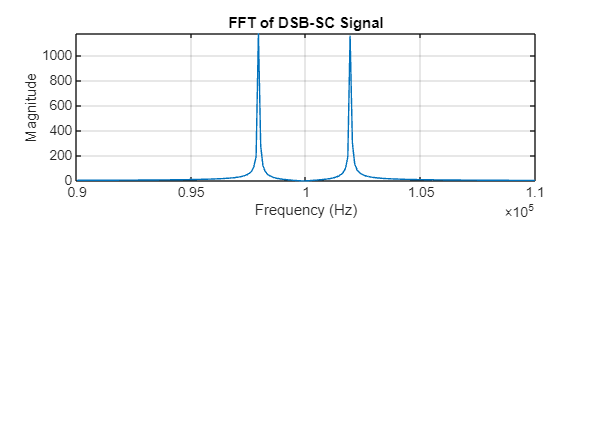

In [10]:
clc;
clear;
close all;

Fs = 500000;
t = 0:1/Fs:0.01;

fm = 2000;
fc = 100000;

m = cos(2*pi*fm*t);

dsb = m .* cos(2*pi*fc*t);

N = length(dsb);

f = (-N/2:N/2-1)*(Fs/N);

S = fftshift(abs(fft(dsb)));

figure;
subplot(2, 1, 1)
plot(f,S);
grid on;
xlabel('Frequency (Hz)');
ylabel('Magnitude');
title('FFT of DSB-SC Signal');
xlim([90000 110000]);